<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 3 — Modelo de lenguaje por caracteres

## Consigna

- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el preprocesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre entrenamiento y validación.
- Proponer arquitecturas de redes neuronales recurrentes para implementar un modelo de lenguaje.
- Evaluar los modelos mediante **perplejidad**.
- Generar nuevas secuencias usando:
  - greedy search,
  - sampling con temperatura,
  - beam search determinístico,
  - beam search estocástico.

En este caso se trabaja con **tokenización por caracteres**, por lo que el vocabulario estará formado por todos los caracteres distintos presentes en el corpus.


In [24]:
import os
import re
import zipfile
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponible: []


### Carga del corpus

In [25]:
EPUB_PATH = "texto.epub"

if not os.path.exists(EPUB_PATH):
    raise FileNotFoundError(
        "No se encontró texto.epub. Subí el archivo al mismo directorio del notebook y volvé a ejecutar."
    )

def extract_text_from_epub(epub_path):
    """Extrae texto plano desde archivos HTML/XHTML contenidos en un EPUB."""
    texts = []

    with zipfile.ZipFile(epub_path, "r") as z:
        html_files = [
            name for name in z.namelist()
            if name.lower().endswith((".html", ".xhtml", ".htm"))
        ]

        print("Cantidad de archivos HTML/XHTML encontrados:", len(html_files))

        for name in html_files:
            raw = z.read(name)
            soup = BeautifulSoup(raw, "html.parser")

            for tag in soup(["script", "style", "nav"]):
                tag.decompose()

            text = soup.get_text(separator=" ")
            text = re.sub(r"\s+", " ", text).strip()

            if len(text) > 100:
                texts.append(text)

    return " ".join(texts)

raw_text = extract_text_from_epub(EPUB_PATH)

print("Cantidad de caracteres extraídos:", len(raw_text))
print(raw_text[:1000])

Cantidad de archivos HTML/XHTML encontrados: 75
Cantidad de caracteres extraídos: 503311
The Project Gutenberg eBook of Essentials of Diseases of the Skin, by Henry Weightman Stelwagon The Project Gutenberg eBook of Essentials of Diseases of the Skin This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever. You may copy it, give it away or re-use it under the terms of the Project Gutenberg License included with this eBook or online at www.gutenberg.org . If you are not located in the United States, you will have to check the laws of the country where you are located before using this eBook. Title : Essentials of Diseases of the Skin Author : Henry Weightman Stelwagon Release date : July 1, 2008 [eBook #25944] Language : English Other information and formats : www.gutenberg.org/ebooks/25944 Credits : E-text prepared by Kevin Handy, Ronnie Sahlberg, cbott, John Hagerson, and the Project Guten

### Preprocesamiento

Se normaliza el texto para reducir ruido. Como el modelo trabaja a nivel carácter, no se eliminan signos completamente, ya que la puntuación ayuda al modelo a aprender estructura textual. Se realizan las siguientes transformaciones: Pasar todo a minúsculas, normalizar espacios, eliminar caracteres de control y limitar opcionalmente la longitud del texto para que el entrenamiento sea razonable en Colab/Jupyter.

In [26]:
def clean_text(text):
    text = text.lower()
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-záéíóúüñ0-9\.,;:!\?¿¡\-\'\"\(\) ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

article_text = clean_text(raw_text)

# Para entrenamiento rápido. Cambiar a None para usar todo el corpus.
MAX_CHARS = 250_000

if MAX_CHARS is not None and len(article_text) > MAX_CHARS:
    article_text = article_text[:MAX_CHARS]

print("Cantidad final de caracteres usados:", len(article_text))
print(article_text[:1000])

Cantidad final de caracteres usados: 250000
the project gutenberg ebook of essentials of diseases of the skin, by henry weightman stelwagon the project gutenberg ebook of essentials of diseases of the skin this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions whatsoever. you may copy it, give it away or re-use it under the terms of the project gutenberg license included with this ebook or online at www.gutenberg.org . if you are not located in the united states, you will have to check the laws of the country where you are located before using this ebook. title : essentials of diseases of the skin author : henry weightman stelwagon release date : july 1, 2008 ebook 25944 language : english other information and formats : www.gutenberg.org ebooks 25944 credits : e-text prepared by kevin handy, ronnie sahlberg, cbott, john hagerson, and the project gutenberg online distributed proofreading team start 

### Tokenización por caracteres

En este enfoque cada carácter es un token.  
Se construyen dos diccionarios:

- `char2idx`: transforma caracteres en índices numéricos.
- `idx2char`: transforma índices numéricos nuevamente en caracteres.

El modelo no recibe texto crudo, sino secuencias de números.


In [27]:
chars_vocab = sorted(list(set(article_text)))
vocab_size = len(chars_vocab)

char2idx = {ch: idx for idx, ch in enumerate(chars_vocab)}
idx2char = {idx: ch for ch, idx in char2idx.items()}

print("Tamaño del vocabulario:", vocab_size)
print("Vocabulario:")
print(chars_vocab)

tokenized_text = np.array([char2idx[ch] for ch in article_text], dtype=np.int32)

print("Primeros 100 tokens:")
print(tokenized_text[:100])

Tamaño del vocabulario: 46
Vocabulario:
[' ', "'", '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Primeros 100 tokens:
[39 27 24  0 35 37 34 29 24 22 39  0 26 40 39 24 33 21 24 37 26  0 24 21
 34 34 30  0 34 25  0 24 38 38 24 33 39 28 20 31 38  0 34 25  0 23 28 38
 24 20 38 24 38  0 34 25  0 39 27 24  0 38 30 28 33  4  0 21 44  0 27 24
 33 37 44  0 42 24 28 26 27 39 32 20 33  0 38 39 24 31 42 20 26 34 33  0
 39 27 24  0]


### Estructuración del dataset

In [28]:
max_context_size = 100  # longitud del contexto
step = 3                # salto entre ventanas; menor = más datos, mayor costo computacional
p_val = 0.10            # proporción de validación

def build_sequences(token_ids, seq_len=100, step=3):
    X, y = [], []

    for start in range(0, len(token_ids) - seq_len - 1, step):
        chunk = token_ids[start:start + seq_len + 1]
        X.append(chunk[:-1])
        y.append(chunk[1:])

    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

split_idx = int(len(tokenized_text) * (1 - p_val))

train_ids = tokenized_text[:split_idx]
val_ids = tokenized_text[split_idx:]

X_train, y_train = build_sequences(train_ids, max_context_size, step)
X_val, y_val = build_sequences(val_ids, max_context_size, step)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("Ejemplo de secuencia de entrada (tokens):")
print(X_train[0])
print("Ejemplo de secuencia objetivo (tokens):")
print(y_train[0])

X_train: (74967, 100)
y_train: (74967, 100)
X_val: (8300, 100)
y_val: (8300, 100)
Ejemplo de secuencia de entrada (tokens):
[39 27 24  0 35 37 34 29 24 22 39  0 26 40 39 24 33 21 24 37 26  0 24 21
 34 34 30  0 34 25  0 24 38 38 24 33 39 28 20 31 38  0 34 25  0 23 28 38
 24 20 38 24 38  0 34 25  0 39 27 24  0 38 30 28 33  4  0 21 44  0 27 24
 33 37 44  0 42 24 28 26 27 39 32 20 33  0 38 39 24 31 42 20 26 34 33  0
 39 27 24  0]
Ejemplo de secuencia objetivo (tokens):
[27 24  0 35 37 34 29 24 22 39  0 26 40 39 24 33 21 24 37 26  0 24 21 34
 34 30  0 34 25  0 24 38 38 24 33 39 28 20 31 38  0 34 25  0 23 28 38 24
 20 38 24 38  0 34 25  0 39 27 24  0 38 30 28 33  4  0 21 44  0 27 24 33
 37 44  0 42 24 28 26 27 39 32 20 33  0 38 39 24 31 42 20 26 34 33  0 39
 27 24  0 35]


### Callback para calcular Perplejidad

In [29]:
class PerplexityCallback(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.train_ppl = []
        self.val_ppl = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        if loss is not None:
            self.train_ppl.append(float(np.exp(loss)))

        if val_loss is not None:
            self.val_ppl.append(float(np.exp(val_loss)))

        print(
            f" - train_ppl: {np.exp(loss):.2f}"
            f" - val_ppl: {np.exp(val_loss):.2f}"
        )

### Elección de modelos recurrentes

Se proponen tres arquitecturas:

1. **SimpleRNN:** modelo recurrente básico.
2. **LSTM:** incorpora compuertas y memoria interna, por lo que puede capturar dependencias más largas.
3. **GRU:** variante más simple que LSTM, con buena relación entre capacidad y costo computacional.

En los tres casos se usa: "Enbedding", capa recurrente con "return_sequence=True" y una capa "Dense" para calcular el próximo carácter.

In [30]:
def build_char_lm(model_type="LSTM", vocab_size=100, embedding_dim=64, rnn_units=128, dropout=0.2):
    model = keras.Sequential(name=f"char_lm_{model_type}")

    model.add(layers.Input(shape=(None,), dtype="int32"))
    model.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    if model_type == "SimpleRNN":
        model.add(layers.SimpleRNN(rnn_units, return_sequences=True, dropout=dropout))
    elif model_type == "LSTM":
        model.add(layers.LSTM(rnn_units, return_sequences=True, dropout=dropout))
    elif model_type == "GRU":
        model.add(layers.GRU(rnn_units, return_sequences=True, dropout=dropout))
    else:
        raise ValueError("model_type debe ser: 'SimpleRNN', 'LSTM' o 'GRU'.")

    model.add(layers.Dense(vocab_size, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy"
    )

    return model

demo_model = build_char_lm("LSTM", vocab_size=vocab_size)
demo_model.summary()

Model: "char_lm_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, None, 64)       │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, None, 128)      │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, None, 46)       │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,694 (420.68 KB)

 Trainable params: 107,694 (420.68 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

Para mantener el tiempo de ejecución bajo control, se entrenan pocas épocas.  
En un trabajo final se puede aumentar `EPOCHS` para mejorar la calidad del texto generado.


In [31]:
EPOCHS = 5
BATCH_SIZE = 256

models_to_train = ["SimpleRNN", "LSTM", "GRU"]

trained_models = {}
histories = {}
ppl_histories = {}

for model_type in models_to_train:
    print("\n" + "="*70)
    print(f"Entrenando modelo: {model_type}")
    print("="*70)

    model = build_char_lm(
        model_type=model_type,
        vocab_size=vocab_size,
        embedding_dim=64,
        rnn_units=128,
        dropout=0.2
    )

    ppl_callback = PerplexityCallback()

    callbacks = [
        ppl_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f"best_{model_type}.keras",
            monitor="val_loss",
            save_best_only=True
        )
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks
    )

    trained_models[model_type] = model
    histories[model_type] = history.history
    ppl_histories[model_type] = {
        "train_ppl": ppl_callback.train_ppl,
        "val_ppl": ppl_callback.val_ppl
    }


Entrenando modelo: SimpleRNN
Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 2.6328 - train_ppl: 10.12 - val_ppl: 7.41
293/293 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - loss: 2.3145 - val_loss: 2.0034
Epoch 2/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.9188 - train_ppl: 6.40 - val_ppl: 5.88
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 1.8564 - val_loss: 1.7716
Epoch 3/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.7084 - train_ppl: 5.34 - val_ppl: 5.22
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 1.6754 - val_loss: 1.6534
Epoch 4/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.5917 - train_ppl: 4.82 - val_ppl: 4.88
293/293 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - loss: 1.5722 - val_loss: 1.5850
Epoch 5/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 1.5194 - train_ppl: 4.51 - val_ppl: 4.66
293/293 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - loss: 1.5069 - val_loss: 1.5389

Entrenando modelo: LSTM
Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step -

### Comparación de modelos
Se compara la perplejidad final de validación de cada modelo, en el cual la mejor arquitectura tendrá la menorm perplejidad. 


In [32]:
results = []

for model_type in models_to_train:
    best_val_loss = min(histories[model_type]["val_loss"])
    best_val_ppl = float(np.exp(best_val_loss))

    results.append({
        "modelo": model_type,
        "mejor_val_loss": best_val_loss,
        "mejor_val_perplexity": best_val_ppl,
        "epochs_entrenadas": len(histories[model_type]["loss"])
    })

results_df = pd.DataFrame(results).sort_values("mejor_val_perplexity")
results_df

,modelo,mejor_val_loss,mejor_val_perplexity,epochs_entrenadas
2,GRU,1.360069,3.896460,5
1,LSTM,1.487795,4.427323,5
0,SimpleRNN,1.538917,4.659542,5


### Gráfico de perplejidad de validación

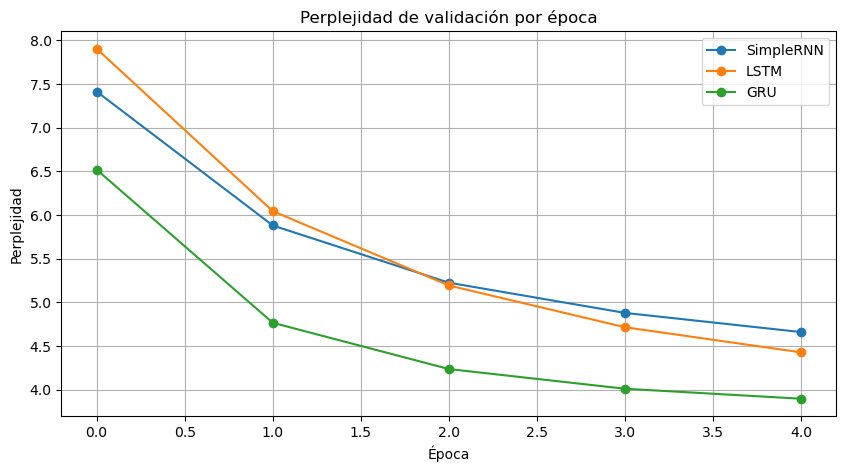

Mejor modelo según perplejidad de validación: GRU


In [33]:
plt.figure(figsize=(10, 5))

for model_type in models_to_train:
    plt.plot(
        ppl_histories[model_type]["val_ppl"],
        marker="o",
        label=model_type
    )

plt.title("Perplejidad de validación por época")
plt.xlabel("Época")
plt.ylabel("Perplejidad")
plt.legend()
plt.grid(True)
plt.show()

best_model_name = results_df.iloc[0]["modelo"]
best_model = trained_models[best_model_name]

print("Mejor modelo según perplejidad de validación:", best_model_name)

## Interpretación de resultados

En general, se espera que `SimpleRNN` funcione como línea base y que `LSTM` o `GRU` obtengan menor perplejidad debido a su capacidad para retener información contextual durante más pasos temporales.

En este caso, `GRU` obtiene un resultado superior a `LSTM`, por lo tanto, se la considera como la arquitectura eficiente paraa este corpus.


### Funciones de generación de texto

A continuación se implementan varias estrategias de decodificación:

1. **Greedy search:** elige siempre el carácter más probable.
2. **Sampling con temperatura:** muestrea desde la distribución de probabilidad ajustada por temperatura.
3. **Beam search determinístico:** mantiene varias secuencias candidatas y elige las más probables.
4. **Beam search estocástico:** introduce muestreo dentro del beam search para generar secuencias más diversas.


In [34]:
def encode_text(text, max_length=max_context_size):
    text = clean_text(text)

    # Filtrar caracteres que no estén en el vocabulario
    text = "".join(ch for ch in text if ch in char2idx)

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences(
        [encoded],
        maxlen=max_length,
        padding="pre",
        truncating="pre"
    )

    return encoded

def decode_ids(ids):
    return "".join(idx2char[int(i)] for i in ids)

def predict_next_probs(model, text):
    encoded = encode_text(text)
    preds = model.predict(encoded, verbose=0)[0, -1, :]
    preds = np.asarray(preds).astype("float64")
    preds = preds / np.sum(preds)
    return preds

def sample_with_temperature(probs, temperature=1.0):
    probs = np.asarray(probs).astype("float64")

    if temperature <= 0:
        raise ValueError("La temperatura debe ser mayor a 0.")

    log_probs = np.log(probs + 1e-12) / temperature
    exp_probs = np.exp(log_probs)
    adjusted_probs = exp_probs / np.sum(exp_probs)

    return np.random.choice(len(adjusted_probs), p=adjusted_probs)

In [35]:
def generate_greedy(model, seed_text, n_chars=300):
    output = clean_text(seed_text)

    for _ in range(n_chars):
        probs = predict_next_probs(model, output)
        next_idx = int(np.argmax(probs))
        output += idx2char[next_idx]

    return output

seed_text = "the "
print(generate_greedy(best_model, seed_text, n_chars=400))

the                                                                                                                                                                                                                                                                                                                                                                                                                


In [36]:
def generate_with_temperature(model, seed_text, n_chars=300, temperature=1.0):
    output = clean_text(seed_text)

    for _ in range(n_chars):
        probs = predict_next_probs(model, output)
        next_idx = sample_with_temperature(probs, temperature=temperature)
        output += idx2char[next_idx]

    return output

for temp in [0.5, 1.0, 1.3]:
    print("\n" + "="*70)
    print(f"Temperatura = {temp}")
    print("="*70)
    print(generate_with_temperature(best_model, seed_text, n_chars=400, temperature=temp))


Temperatura = 0.5
the                                                                                                                                                                                                                                                                                                                                                                                                                

Temperatura = 1.0
the           kyper  rounded  ,             dermatitis  .               ) ?   iirtham;                                                .t.                                               .................. .......... ................. ........... .......................)      ....................... ........................... ...........................-x.  ......... ............................. .....

Temperatura = 1.3
the      symptoms.                            ) , ymidles,                                                                             

In [37]:
def beam_search_generate(
    model,
    seed_text,
    n_chars=200,
    num_beams=5,
    temperature=1.0,
    mode="det"
):
    """
    mode='det': beam search determinístico.
    mode='stoch': beam search estocástico.
    """

    seed_text = clean_text(seed_text)
    beams = [(seed_text, 0.0)]  # (texto, log_prob acumulada)

    for _ in range(n_chars):
        candidates = []

        for text, score in beams:
            probs = predict_next_probs(model, text)

            if temperature != 1.0:
                log_probs = np.log(probs + 1e-12) / temperature
                probs = np.exp(log_probs)
                probs = probs / probs.sum()

            if mode == "det":
                top_idx = np.argsort(probs)[::-1][:num_beams]
            elif mode == "stoch":
                top_idx = np.random.choice(
                    len(probs),
                    size=num_beams,
                    replace=False,
                    p=probs
                )
            else:
                raise ValueError("mode debe ser 'det' o 'stoch'.")

            for idx in top_idx:
                next_char = idx2char[int(idx)]
                next_score = score + np.log(probs[int(idx)] + 1e-12)
                candidates.append((text + next_char, next_score))

        candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
        beams = candidates[:num_beams]

    return beams

beam_outputs_det = beam_search_generate(
    best_model,
    seed_text,
    n_chars=300,
    num_beams=5,
    temperature=1.0,
    mode="det"
)

print("Beam search determinístico:")
print(beam_outputs_det[0][0])

Beam search determinístico:
these                                                                                                                                                                                                                                                                                                          


In [38]:
beam_outputs_stoch = beam_search_generate(
    best_model,
    seed_text,
    n_chars=300,
    num_beams=5,
    temperature=1.1,
    mode="stoch"
)

print("Beam search estocástico:")
print(beam_outputs_stoch[0][0])

Beam search estocástico:
these                                                                                                                                                                                                                                                                                                          


### Análisis de las estrategias de generación

**Greedy search** suele producir texto estable, pero al eligir el carácter de máxima probabilidad puede volverse repititivo.

**Sampling con temperatura** permite controlar la aleatoriedad: con temperatura baja el texto es más conservador y predecible mientras que con temperatura alta, aumenta la creatividad pero pueden aparecer más errores.


**Beam search determinístico** conserva varias hipótesis candidatas y selecciona la secuencia globalmente más probable dentro del ancho del haz. 

**Beam search estocástico** combina exploración y probabilidad. Al muestrear candidatos, puede producir secuencias más variadas, aunque menos estables.